<a href="https://colab.research.google.com/github/mananmalvi/ML--The-Art/blob/main/DAY-15-Sentinel_X_%7C_AdaBoost_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧹 PHASE 1: DATA INGESTION & SANITATION

In [ ]:
import pandas as pd
import numpy as np

print("🏭 Initiating Sentinel-X: Fetching AI4I 2020 Industrial Telemetry...")

# ==========================================
# 🧹 PHASE 1: DATA INGESTION & SANITATION
# ==========================================
# Fetching the official AI4I 2020 Predictive Maintenance Dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

# 1. Strip Non-Predictive Metadata (UDI and Product ID hold no predictive value)
df = df.drop(['UDI', 'Product ID'], axis=1)

# 2. Ordinal Encoding for Machine Quality Variant
# L (Low) = 50%, M (Medium) = 30%, H (High) = 20% of the machines.
quality_map = {'L': 0, 'M': 1, 'H': 2}
df['Type'] = df['Type'].map(quality_map)

# 3. Clean up column names (Removing spaces and brackets like '[K]' and '[rpm]' for cleaner code)
df.columns = df.columns.str.replace(' ', '_').str.replace('[\[\]]', '', regex=True)

print(f"✅ Data Ingestion Complete. Radar tracking {df.shape[0]} machine records.")



<>:22: SyntaxWarning: invalid escape sequence '\['
<>:22: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_1435/2192513659.py:22: SyntaxWarning: invalid escape sequence '\['
  df.columns = df.columns.str.replace(' ', '_').str.replace('[\[\]]', '', regex=True)


🏭 Initiating Sentinel-X: Fetching AI4I 2020 Industrial Telemetry...
✅ Data Ingestion Complete. Radar tracking 10000 machine records.


 # ⚙️ PHASE 2: PHYSICS-BASED FEATURE ENGINEERING

In [ ]:

# ==========================================
# ⚙️ PHASE 2: PHYSICS-BASED FEATURE ENGINEERING
# ==========================================
print("⚙️ Engineering Thermodynamic & Mechanical Features...")

# 1. Thermal Dissipation Delta (Temperature difference)
# Heat transfer (and overheating risk) is driven by the delta between process and ambient air.
df['Temp_Delta'] = df['Process_temperature_K'] - df['Air_temperature_K']

# 2. Mechanical Power (W)
# Power is physically coupled to Torque and RPM.
# Formula: P = (2 * pi * Torque * RPM) / 60
df['Mechanical_Power_W'] = (2 * np.pi * df['Torque_Nm'] * df['Rotational_speed_rpm']) / 60

# 3. Overstrain Index
# Combines cumulative tool wear with current active torque to flag extreme mechanical stress.
df['Overstrain_Index'] = df['Tool_wear_min'] * df['Torque_Nm']

# ==========================================
# 🔍 QUICK SYSTEM DIAGNOSTICS
# ==========================================
print("\n📊 Engineered Dataset Snapshot (First 5 Rows):")
display(df[['Type', 'Temp_Delta', 'Mechanical_Power_W', 'Overstrain_Index', 'Machine_failure']].head())

print("\n🔥 Target Distribution (Machine Failure):")
print(df['Machine_failure'].value_counts())
print(f"\n⚠️ Imbalance Alert: Only {(df['Machine_failure'].mean() * 100):.2f}% of the records are actual failures.")

⚙️ Engineering Thermodynamic & Mechanical Features...

📊 Engineered Dataset Snapshot (First 5 Rows):


,Type,Temp_Delta,Mechanical_Power_W,Overstrain_Index,Machine_failure
0,1,10.5,6951.590560,0.0,0
1,0,10.5,6826.722724,138.9,0
2,0,10.4,7749.387543,247.0,0
3,0,10.4,5927.504659,276.5,0
4,0,10.5,5897.816608,360.0,0



🔥 Target Distribution (Machine Failure):
Machine_failure
0    9661
1     339
Name: count, dtype: int64

⚠️ Imbalance Alert: Only 3.39% of the records are actual failures.


# 📊 PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)

📊 Initiating Sentinel-X Phase 3: Industrial Sensor Audit...


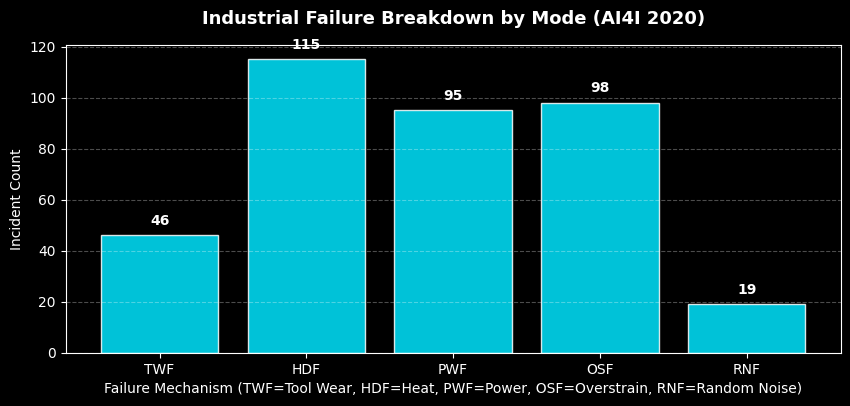

In [ ]:
# ==========================================
# 📊 PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set dark industrial styling
plt.style.use('dark_background')
palette = ['#00e5ff', '#ff3366']  # Cyan (Nominal) vs Neon Red (Failure)

print("📊 Initiating Sentinel-X Phase 3: Industrial Sensor Audit...")

# ------------------------------------------
# 1️⃣ Failure Mode Decomposition (The 5 Failure Modes)
# ------------------------------------------
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_counts = df[failure_modes].sum()

plt.figure(figsize=(10, 4))
bars = plt.bar(failure_counts.index, failure_counts.values, color='#00e5ff', edgecolor='white', alpha=0.85)
plt.title("Industrial Failure Breakdown by Mode (AI4I 2020)", fontsize=13, weight='bold', pad=15)
plt.ylabel("Incident Count")
plt.xlabel("Failure Mechanism (TWF=Tool Wear, HDF=Heat, PWF=Power, OSF=Overstrain, RNF=Random Noise)")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 3, int(yval), ha='center', va='bottom', color='white', weight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()



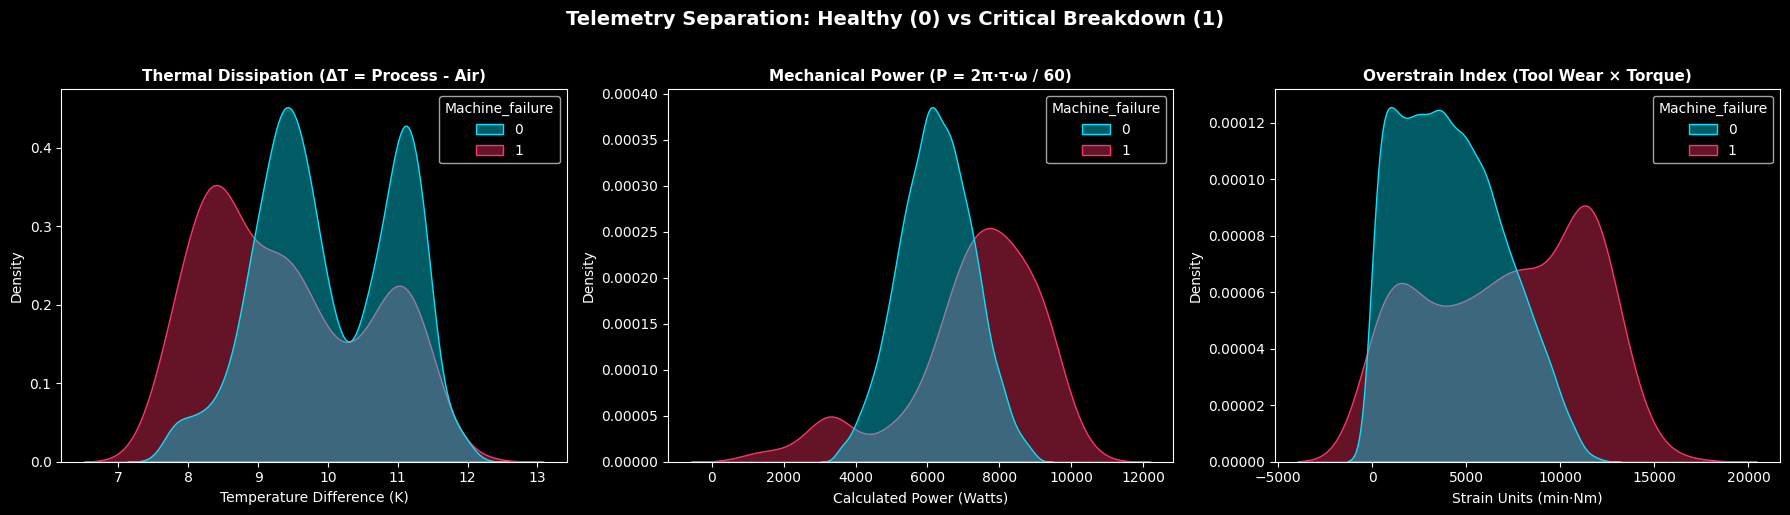

In [ ]:
# ------------------------------------------
# 2️⃣ Physical Sensor Distributions (Engineered Features)
# ------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Thermal Dissipation Delta
sns.kdeplot(data=df, x='Temp_Delta', hue='Machine_failure', common_norm=False, fill=True,
            palette=palette, alpha=0.4, ax=axes[0])
axes[0].set_title("Thermal Dissipation (ΔT = Process - Air)", fontsize=11, weight='bold')
axes[0].set_xlabel("Temperature Difference (K)")

# Plot 2: Mechanical Power (W)
sns.kdeplot(data=df, x='Mechanical_Power_W', hue='Machine_failure', common_norm=False, fill=True,
            palette=palette, alpha=0.4, ax=axes[1])
axes[1].set_title("Mechanical Power (P = 2π·τ·ω / 60)", fontsize=11, weight='bold')
axes[1].set_xlabel("Calculated Power (Watts)")

# Plot 3: Overstrain Index
sns.kdeplot(data=df, x='Overstrain_Index', hue='Machine_failure', common_norm=False, fill=True,
            palette=palette, alpha=0.4, ax=axes[2])
axes[2].set_title("Overstrain Index (Tool Wear × Torque)", fontsize=11, weight='bold')
axes[2].set_xlabel("Strain Units (min·Nm)")

plt.suptitle("Telemetry Separation: Healthy (0) vs Critical Breakdown (1)", fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()


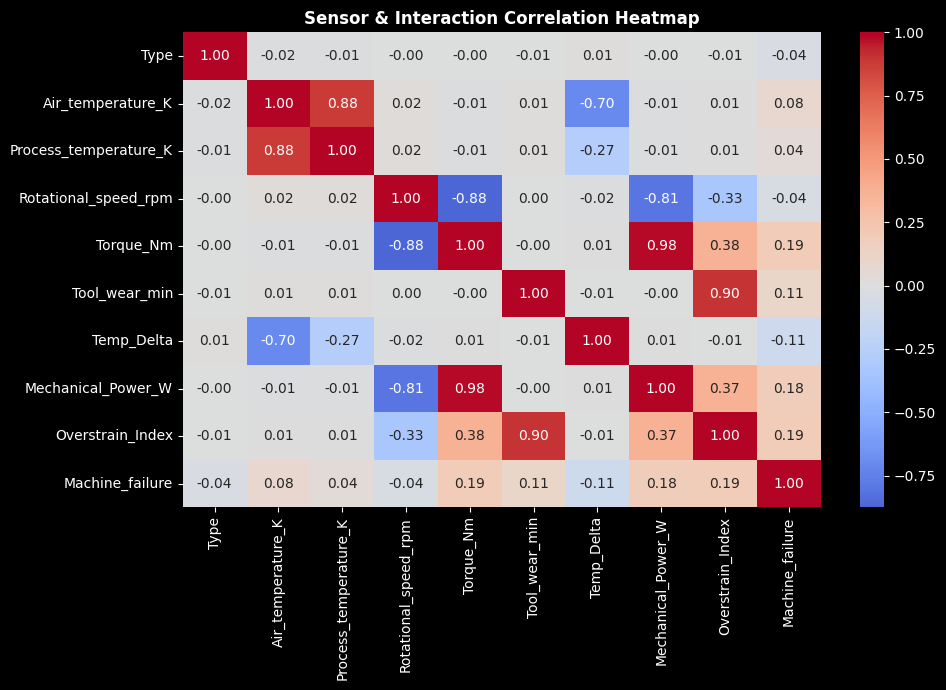

In [ ]:
# ------------------------------------------
# 3️⃣ Correlation Matrix of Engineered Telemetry
# ------------------------------------------
corr_cols = ['Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm',
             'Torque_Nm', 'Tool_wear_min', 'Temp_Delta', 'Mechanical_Power_W',
             'Overstrain_Index', 'Machine_failure']

plt.figure(figsize=(10, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar=True)
plt.title("Sensor & Interaction Correlation Heatmap", fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

# ⚔️ PHASE 4: MODEL BENCHMARKING & BIAS-VARIANCE COMPARISON

In [ ]:
# =====================================================================
# ⚔️ PHASE 4: MODEL BENCHMARKING & BIAS-VARIANCE COMPARISON
# =====================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

print("🛡️ Initiating Sentinel-X Phase 4: Benchmarking Protocol...\n")

# ---------------------------------------------------------------------
# 1️⃣ Target & Feature Separation (Zero Data Leakage)
# ---------------------------------------------------------------------
# Drop target AND specific failure mode flags to avoid target leakage
leakage_cols = ['Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
feature_cols = [col for col in df.columns if col not in leakage_cols]

X = df[feature_cols]
y = df['Machine_failure']

print(f"Features in Scope ({len(feature_cols)}): {feature_cols}")

🛡️ Initiating Sentinel-X Phase 4: Benchmarking Protocol...

Features in Scope (9): ['Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Temp_Delta', 'Mechanical_Power_W', 'Overstrain_Index']


In [ ]:
# ---------------------------------------------------------------------
# 2️⃣ Stratified Train-Test Split (80/20)
# ---------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature Scaling (Fit on Train, Transform on Test)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

print(f"Data Partition Complete: Train = {X_train.shape[0]} | Test = {X_test.shape[0]}\n")


Data Partition Complete: Train = 8000 | Test = 2000



In [ ]:
# ---------------------------------------------------------------------
# 3️⃣ Define The Arena (The 4 Contenders)
# ---------------------------------------------------------------------
models = {
    "1. Decision Stump (Depth=1)": DecisionTreeClassifier(max_depth=1, random_state=42),
    "2. Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "3. Random Forest (100 Trees)": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    "4. AdaBoost (100 Stumps)": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    )
}

In [ ]:
# ---------------------------------------------------------------------
# 4️⃣ Benchmarking Engine
# ---------------------------------------------------------------------
benchmark_results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # Use scaled data for Logistic Regression, standard data for tree-based models
    if "Logistic" in name:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test

    # Train
    model.fit(X_tr, y_train)

    # Predictions
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    # Cross-Validation F1 (Macro/Minority)
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='f1', n_jobs=-1)

    benchmark_results.append({
        "Model Architecture": name,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall (Safety Critical)": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba),
        "CV F1 Mean": cv_scores.mean(),
        "CV F1 Std (Stability)": cv_scores.std()
    })

# Convert to DataFrame
leaderboard = pd.DataFrame(benchmark_results).set_index("Model Architecture")
print("🏆 SENTINEL-X MODEL BENCHMARK LEADERBOARD:")
display(leaderboard.round(4))

🏆 SENTINEL-X MODEL BENCHMARK LEADERBOARD:


,Precision,Recall (Safety Critical),F1-Score,ROC-AUC,PR-AUC,CV F1 Mean,CV F1 Std (Stability)
Model Architecture,,,,,,,
1. Decision Stump (Depth=1),0.8182,0.2647,0.4000,0.6313,0.2416,0.4423,0.0775
2. Logistic Regression,0.1780,0.8824,0.2963,0.9393,0.4336,0.2719,0.0126
3. Random Forest (100 Trees),0.9615,0.7353,0.8333,0.9753,0.8644,0.8496,0.0383
4. AdaBoost (100 Stumps),0.9167,0.3235,0.4783,0.9632,0.7469,0.5066,0.0521


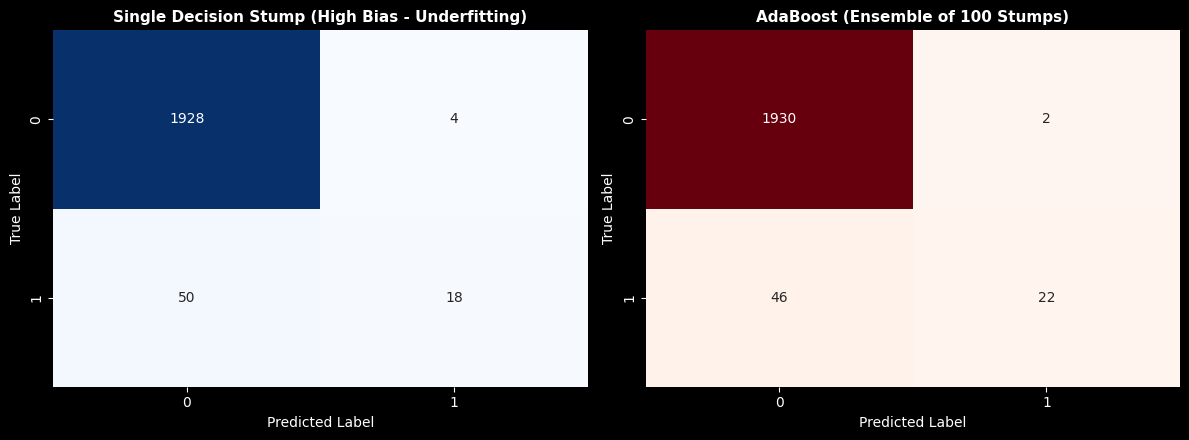

In [ ]:
# ---------------------------------------------------------------------
# 5️⃣ Confusion Matrix: AdaBoost vs Single Stump
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Stump Confusion Matrix
stump_pred = models["1. Decision Stump (Depth=1)"].predict(X_test)
sns.heatmap(confusion_matrix(y_test, stump_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title("Single Decision Stump (High Bias - Underfitting)", fontsize=11, weight='bold')
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# AdaBoost Confusion Matrix
ada_pred = models["4. AdaBoost (100 Stumps)"].predict(X_test)
sns.heatmap(confusion_matrix(y_test, ada_pred), annot=True, fmt='d', cmap='Reds', ax=axes[1], cbar=False)
axes[1].set_title("AdaBoost (Ensemble of 100 Stumps)", fontsize=11, weight='bold')
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

# 🎛️ PHASE 5: HYPERPARAMETER TUNING & NOISE RESILIENCE LAB

In [ ]:
# =====================================================================
# 🎛️ PHASE 5: HYPERPARAMETER TUNING & NOISE RESILIENCE LAB
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, f1_score, recall_score,
    average_precision_score, precision_recall_curve
)

print("🎛️ Initiating Sentinel-X Phase 5: Tuning & Noise Protocols...\n")

# ---------------------------------------------------------------------
# 1️⃣ GridSearchCV: Optimizing AdaBoost for Imbalanced Telemetry
# ---------------------------------------------------------------------
# Target 'f1' to balance Precision and Recall on the ~3.4% failure class
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.5, 1.0],
    'estimator': [
        DecisionTreeClassifier(max_depth=1),  # Classic Decision Stump
        DecisionTreeClassifier(max_depth=2)   # 2-level stump for interaction capture
    ]
}

ada_base = AdaBoostClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=ada_base,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("🔍 Tuning AdaBoost hyperparameters across cross-validation folds...")
grid_search.fit(X_train, y_train)

best_ada = grid_search.best_estimator_
print("\n🏆 OPTIMAL ADABOOST PARAMETERS:")
for k, v in grid_search.best_params_.items():
    print(f"   - {k}: {v}")

# Evaluate Tuned Model on Test Set
y_pred_tuned = best_ada.predict(X_test)
y_proba_tuned = best_ada.predict_proba(X_test)[:, 1]

print("\n📊 Tuned AdaBoost Diagnostics:")
print(f"   - Test F1-Score: {f1_score(y_test, y_pred_tuned):.4f}")
print(f"   - Test Recall:   {recall_score(y_test, y_pred_tuned):.4f}")
print(f"   - Test PR-AUC:   {average_precision_score(y_test, y_proba_tuned):.4f}")


🎛️ Initiating Sentinel-X Phase 5: Tuning & Noise Protocols...

🔍 Tuning AdaBoost hyperparameters across cross-validation folds...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

🏆 OPTIMAL ADABOOST PARAMETERS:
   - estimator: DecisionTreeClassifier(max_depth=2)
   - learning_rate: 0.5
   - n_estimators: 150

📊 Tuned AdaBoost Diagnostics:
   - Test F1-Score: 0.8174
   - Test Recall:   0.6912
   - Test PR-AUC:   0.9015



🧪 Running Noise Resilience Experiment on RNF (Random Failure) Cases...
   - Isolated 4 pure random noise failures in test slice.


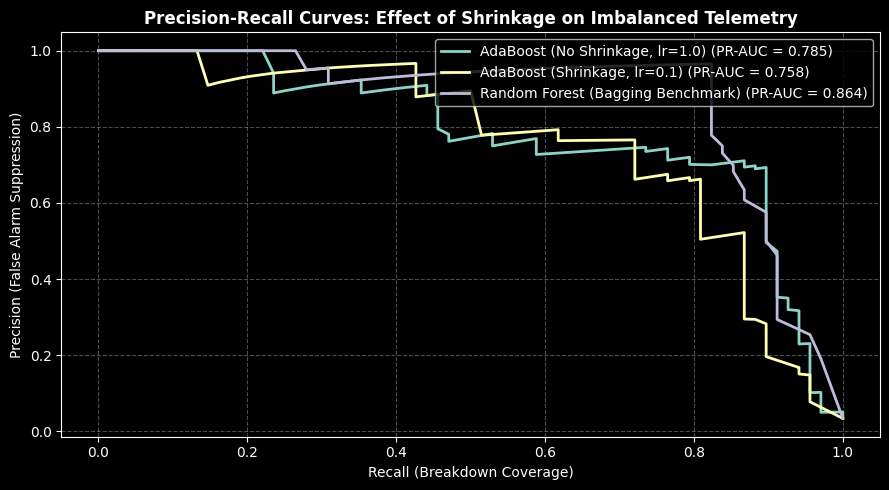

In [ ]:
# ---------------------------------------------------------------------
# 2️⃣ THE NOISE SENSITIVITY EXPERIMENT (AdaBoost vs Random Forest)
# ---------------------------------------------------------------------
# AI4I 2020 has 'RNF' (Random Failures) that have zero physical sensor correlation.
# Let's assess how different models handle these noisy points.

print("\n🧪 Running Noise Resilience Experiment on RNF (Random Failure) Cases...")

# Identify RNF indices in test set
rnf_test_indices = df.loc[X_test.index][df.loc[X_test.index]['RNF'] == 1].index
print(f"   - Isolated {len(rnf_test_indices)} pure random noise failures in test slice.")

# Define 3 configurations to compare:
# 1. Aggressive AdaBoost (no shrinkage: lr=1.0)
# 2. Regularized AdaBoost (with shrinkage: lr=0.1)
# 3. Random Forest (Parallel Bagging benchmark)
exp_models = {
    "AdaBoost (No Shrinkage, lr=1.0)": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100, learning_rate=1.0, random_state=42
    ),
    "AdaBoost (Shrinkage, lr=0.1)": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100, learning_rate=0.1, random_state=42
    ),
    "Random Forest (Bagging Benchmark)": RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
    )
}

# Track test set PR curves
plt.figure(figsize=(9, 5))
for label, m in exp_models.items():
    m.fit(X_train, y_train)
    probs = m.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    plt.plot(recall, precision, lw=2, label=f"{label} (PR-AUC = {ap:.3f})")

plt.title("Precision-Recall Curves: Effect of Shrinkage on Imbalanced Telemetry", fontsize=12, weight='bold')
plt.xlabel("Recall (Breakdown Coverage)")
plt.ylabel("Precision (False Alarm Suppression)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


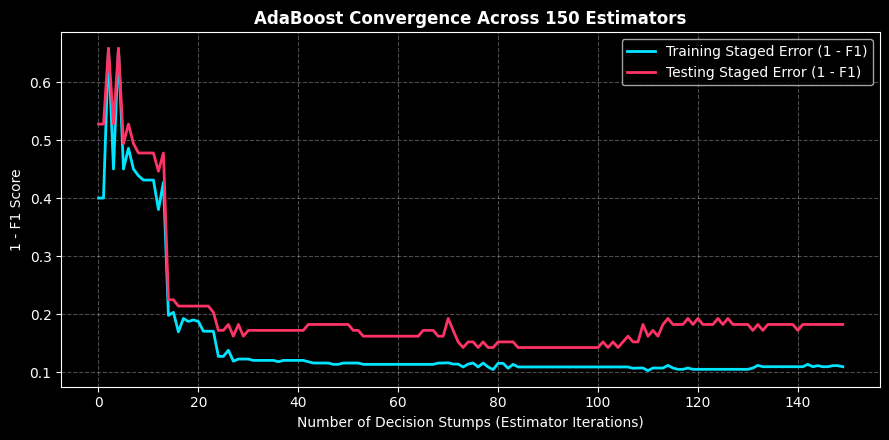

In [ ]:
# ---------------------------------------------------------------------
# 3️⃣ Sequential Estimator Growth: Error Progression
# ---------------------------------------------------------------------
# Observe staged training vs testing error across boosting stages
staged_train_errors = []
staged_test_errors = []

for train_pred, test_pred in zip(best_ada.staged_predict(X_train), best_ada.staged_predict(X_test)):
    staged_train_errors.append(1.0 - f1_score(y_train, train_pred, zero_division=0))
    staged_test_errors.append(1.0 - f1_score(y_test, test_pred, zero_division=0))

plt.figure(figsize=(9, 4.5))
plt.plot(staged_train_errors, label="Training Staged Error (1 - F1)", color="#00e5ff", lw=2)
plt.plot(staged_test_errors, label="Testing Staged Error (1 - F1)", color="#ff3366", lw=2)
plt.title(f"AdaBoost Convergence Across {best_ada.n_estimators} Estimators", fontsize=12, weight='bold')
plt.xlabel("Number of Decision Stumps (Estimator Iterations)")
plt.ylabel("1 - F1 Score")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 🧠 PHASE 6: MACHINE HEALTH ENGINE & EXPLAINABLE AI (XAI)

In [ ]:
# =====================================================================
# 🧠 PHASE 6: MACHINE HEALTH ENGINE & EXPLAINABLE AI (XAI)
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

print("🧠 Initiating Phase 6: Sentinel-X Health Engine & Diagnostics...\n")

# ---------------------------------------------------------------------
# 1️⃣ The Machine Health & Risk Assessment Engine
# ---------------------------------------------------------------------
# Extracting the probability of failure (Class 1) from our tuned AdaBoost model
y_pred_proba = best_ada.predict_proba(X_test)[:, 1]

def calculate_health_metrics(probability):
    """Converts raw ML probability into an industrial Health Score and Risk Tier."""
    # Health Score is the inverse of failure probability (scaled to 100)
    health_score = int(np.round(100 * (1.0 - probability)))

    # 3-Tier Industrial Risk Engine
    if probability < 0.25:
        risk_tier = "🟢 NORMAL"
    elif probability < 0.65:
        risk_tier = "🟠 WARNING (MAINTENANCE REQUIRED)"
    else:
        risk_tier = "🔴 CRITICAL (BREAKDOWN IMMINENT)"

    return health_score, risk_tier

# Simulate live telemetry feed for the first 10 test machines
print("📊 LIVE TELEMETRY FEED (Sentinel-X Engine):")
print("-" * 65)
print(f"{'Machine ID':<12} | {'Failure Prob':<15} | {'Health Score':<15} | {'Risk Tier'}")
print("-" * 65)

for i in range(10):
    prob = y_pred_proba[i]
    health, risk = calculate_health_metrics(prob)
    print(f"Asset-{i+100:<6} | {prob*100:>5.1f}%          | {health:>3}/100          | {risk}")


🧠 Initiating Phase 6: Sentinel-X Health Engine & Diagnostics...

📊 LIVE TELEMETRY FEED (Sentinel-X Engine):
-----------------------------------------------------------------
Machine ID   | Failure Prob    | Health Score    | Risk Tier
-----------------------------------------------------------------
Asset-100    |  38.1%          |  62/100          | 🟠 WARNING (MAINTENANCE REQUIRED)
Asset-101    |  24.1%          |  76/100          | 🟢 NORMAL
Asset-102    |  42.6%          |  57/100          | 🟠 WARNING (MAINTENANCE REQUIRED)
Asset-103    |  23.4%          |  77/100          | 🟢 NORMAL
Asset-104    |  39.0%          |  61/100          | 🟠 WARNING (MAINTENANCE REQUIRED)
Asset-105    |  31.2%          |  69/100          | 🟠 WARNING (MAINTENANCE REQUIRED)
Asset-106    |  41.6%          |  58/100          | 🟠 WARNING (MAINTENANCE REQUIRED)
Asset-107    |  26.5%          |  74/100          | 🟠 WARNING (MAINTENANCE REQUIRED)
Asset-108    |  21.2%          |  79/100          | 🟢 NORMAL
Asset-

/tmp/ipykernel_1435/688226734.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:7], y=features[indices][:7], palette="Reds_r")


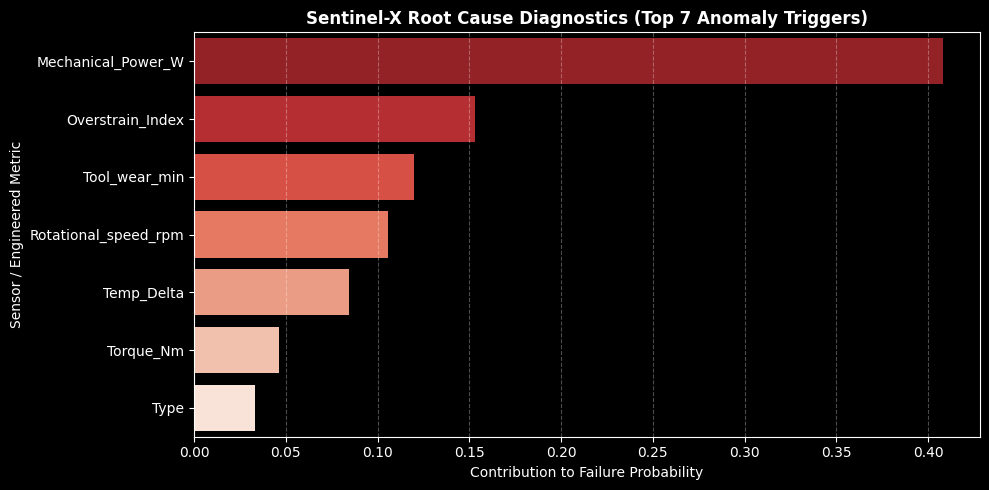

In [ ]:
# ---------------------------------------------------------------------
# 2️⃣ Root Cause Diagnostics (Feature Importance)
# ---------------------------------------------------------------------
# Extracting what specific physical sensors AdaBoost relied on the most
importances = best_ada.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices][:7], y=features[indices][:7], palette="Reds_r")
plt.title("Sentinel-X Root Cause Diagnostics (Top 7 Anomaly Triggers)", fontsize=12, weight='bold')
plt.xlabel("Contribution to Failure Probability")
plt.ylabel("Sensor / Engineered Metric")
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


🔍 Initializing SHAP Values for Deep Explainability...


ExactExplainer explainer: 101it [00:49,  1.95it/s]


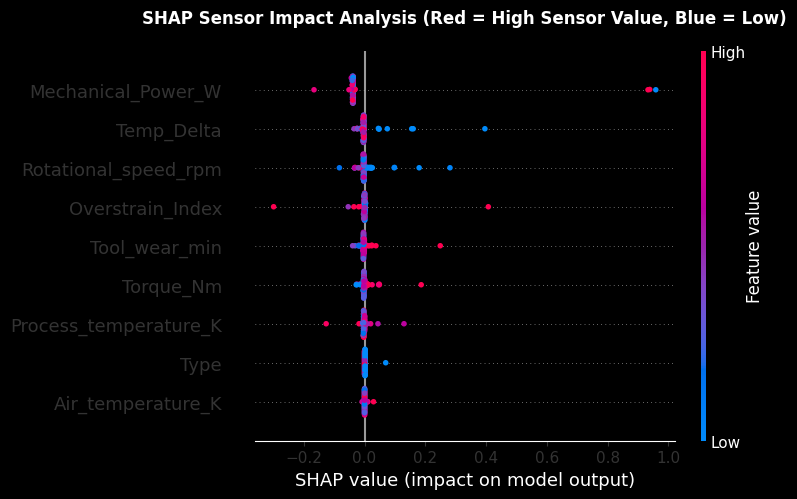

In [ ]:
# ---------------------------------------------------------------------
# 3️⃣ Explainable AI (SHAP) - Local Asset Explanation
# ---------------------------------------------------------------------
print("\n🔍 Initializing SHAP Values for Deep Explainability...")
# Note: AdaBoost uses additive stumps, so we use the model-agnostic Explainer or KernelExplainer
# Using a sample of background data to keep computation fast
background_data = shap.sample(X_train, 100)
explainer = shap.Explainer(best_ada.predict, background_data)
shap_values = explainer(X_test.iloc[:100]) # Explaining the first 100 test samples

# Generate a SHAP Summary Plot to show how high/low sensor values push the risk score
plt.figure(figsize=(10, 6))
plt.title("SHAP Sensor Impact Analysis (Red = High Sensor Value, Blue = Low)", pad=20, weight='bold')
shap.summary_plot(shap_values, X_test.iloc[:100], show=False)
plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# 📦 STEP 4: EXPORTING THE CORE ENGINE FOR DEPLOYMENT
# =====================================================================
import pickle
model_path = "Sentinel-X_Adaboost.pkl"

with open(model_path, "wb") as file:
    pickle.dump(best_ada, file)

print(f"\n✅ SUCCESS: Sentinel-X Engine packed and saved as '{model_path}'.")


✅ SUCCESS: Sentinel-X Engine packed and saved as 'Sentinel-X_Adaboost.pkl'.
